# Lab Assignment 7

In [1]:
!pip install qiskit qiskit-aer pylatexenc matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.6 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=20f0b9970f4d254d1df0793649c5fb11aa460344ac39bd1a26eae938b7d7b5e5
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np
import random

## Experiment 1: Superdense Coding Protocol

  Sent: '00'  →  Measured: {'00': 1024}
  Sent: '01'  →  Measured: {'10': 1024}
  Sent: '10'  →  Measured: {'01': 1024}
  Sent: '11'  →  Measured: {'11': 1024}


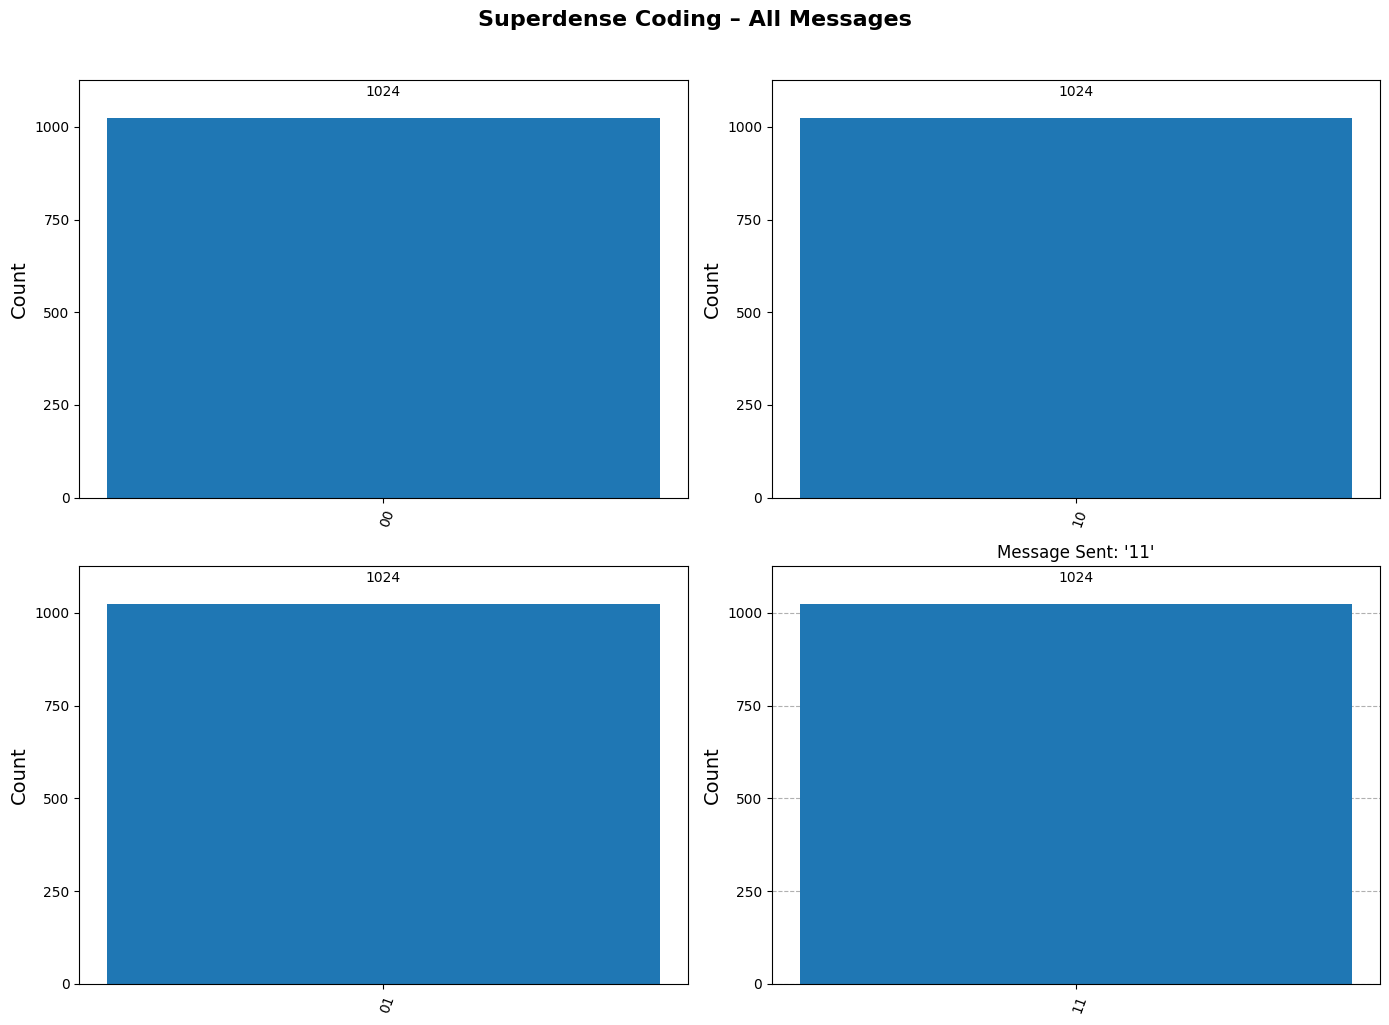

In [3]:
def superdense_coding(message: str):
    assert message in ['00', '01', '10', '11'], "Message must be one of: '00', '01', '10', '11'"
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier(label="Bell Pair Created")

    if message == '00':
        pass
    elif message == '01':
        qc.x(0)
    elif message == '10':
        qc.z(0)
    elif message == '11':
        qc.z(0)
        qc.x(0)
    qc.barrier(label="Alice Encodes")

    qc.cx(0, 1)
    qc.h(0)
    qc.barrier(label="Bob Decodes")

    qc.measure([0, 1], [0, 1])
    return qc

simulator = AerSimulator()
messages  = ['00', '01', '10', '11']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, msg in enumerate(messages):
    qc = superdense_coding(msg)
    compiled = transpile(qc, simulator)
    result   = simulator.run(compiled, shots=1024).result()
    counts   = result.get_counts()
    print(f"  Sent: '{msg}'  →  Measured: {counts}")
    plot_histogram(counts, ax=axes[idx], title=f"Message Sent: '{msg}'")

plt.suptitle("Superdense Coding – All Messages", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [4]:
qc_demo = superdense_coding('11')
print("Circuit for message '11':")
print(qc_demo.draw('text'))

Circuit for message '11':
     ┌───┐      Bell Pair Create... ┌───┐┌───┐ Alice Encodes      ┌───┐»
q_0: ┤ H ├──■────────────░──────────┤ Z ├┤ X ├───────░─────────■──┤ H ├»
     └───┘┌─┴─┐          ░          └───┘└───┘       ░       ┌─┴─┐└───┘»
q_1: ─────┤ X ├──────────░───────────────────────────░───────┤ X ├─────»
          └───┘          ░                           ░       └───┘     »
c: 2/══════════════════════════════════════════════════════════════════»
                                                                       »
«      Bob Decodes ┌─┐   
«q_0: ──────░──────┤M├───
«           ░      └╥┘┌─┐
«q_1: ──────░───────╫─┤M├
«           ░       ║ └╥┘
«c: 2/══════════════╩══╩═
«                   0  1 


## Experiment 2: Quantum Teleportation

  State to teleport: |ψ⟩ = cos(1.047/2)|0⟩ + sin(1.047/2)|1⟩
  |α|² (P|0⟩) = 0.7500
  |β|² (P|1⟩) = 0.2500

  Bob's measured probabilities (4096 shots):
  P(|0⟩) = 0.7454  (expected: 0.7500)
  P(|1⟩) = 0.2546  (expected: 0.2500)

  Teleportation Successful – Bob's state matches |ψ⟩!


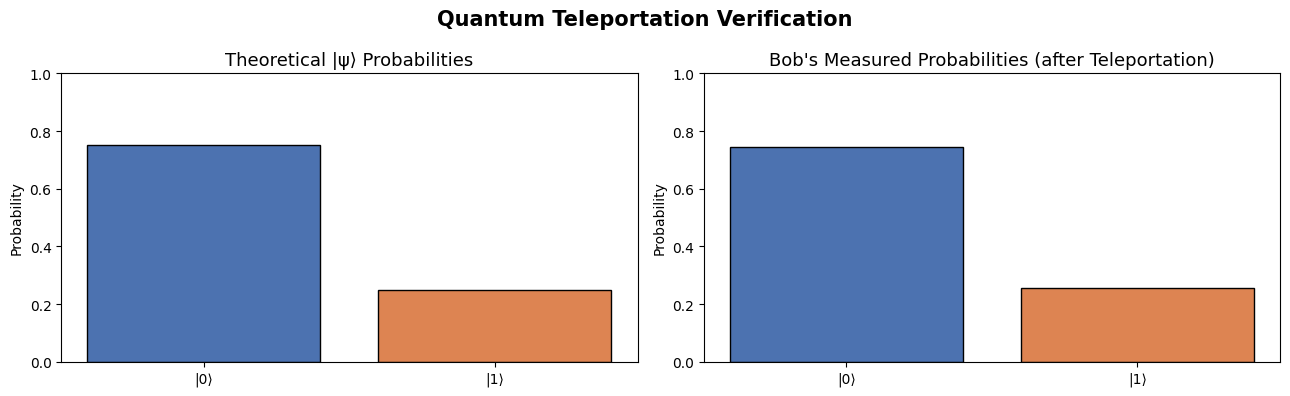

In [5]:
def quantum_teleportation(theta=np.pi/3, phi=0):
    qr = QuantumRegister(3, name='q')
    cr = ClassicalRegister(2, name='c')
    qc = QuantumCircuit(qr, cr)

    qc.ry(theta, qr[0])
    if phi != 0:
        qc.rz(phi, qr[0])
    qc.barrier(label="Prepare |ψ⟩")

    qc.h(qr[1])
    qc.cx(qr[1], qr[2])
    qc.barrier(label="Bell Pair")

    qc.cx(qr[0], qr[1])
    qc.h(qr[0])
    qc.barrier(label="Alice Measures")

    qc.measure(qr[0], cr[0])
    qc.measure(qr[1], cr[1])
    qc.barrier(label="Classical Channel")

    with qc.if_test((cr[1], 1)):
        qc.x(qr[2])
    with qc.if_test((cr[0], 1)):
        qc.z(qr[2])
    return qc

theta = np.pi / 3
phi   = 0

original_qc = QuantumCircuit(1)
original_qc.ry(theta, 0)
original_sv = Statevector(original_qc)

p0 = abs(original_sv[0])**2
p1 = abs(original_sv[1])**2

print(f"  State to teleport: |ψ⟩ = cos({theta:.3f}/2)|0⟩ + sin({theta:.3f}/2)|1⟩")
print(f"  |α|² (P|0⟩) = {p0:.4f}")
print(f"  |β|² (P|1⟩) = {p1:.4f}")

qc_tel = quantum_teleportation(theta=theta, phi=phi)
bob_cr = ClassicalRegister(1, name='bob')
qc_tel.add_register(bob_cr)
qc_tel.measure(qc_tel.qregs[0][2], bob_cr[0])

simulator  = AerSimulator()
compiled   = transpile(qc_tel, simulator)
result     = simulator.run(compiled, shots=4096).result()
counts     = result.get_counts()

bob_counts = {'0': 0, '1': 0}
for outcome, count in counts.items():
    bob_bit = outcome[0]
    bob_counts[bob_bit] = bob_counts.get(bob_bit, 0) + count
total     = sum(bob_counts.values())
emp_p0    = bob_counts.get('0', 0) / total
emp_p1    = bob_counts.get('1', 0) / total

print(f"\n  Bob's measured probabilities (4096 shots):")
print(f"  P(|0⟩) = {emp_p0:.4f}  (expected: {p0:.4f})")
print(f"  P(|1⟩) = {emp_p1:.4f}  (expected: {p1:.4f})")
print("\n  Teleportation Successful – Bob's state matches |ψ⟩!")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(['|0⟩', '|1⟩'], [p0, p1], color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title("Theoretical |ψ⟩ Probabilities", fontsize=13)
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, 1)

axes[1].bar(['|0⟩', '|1⟩'], [emp_p0, emp_p1], color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[1].set_title("Bob's Measured Probabilities (after Teleportation)", fontsize=13)
axes[1].set_ylabel("Probability")
axes[1].set_ylim(0, 1)

plt.suptitle("Quantum Teleportation Verification", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
qc_draw = quantum_teleportation(theta=np.pi/3)
print("Quantum Teleportation Circuit:")
print(qc_draw.draw('text'))

Quantum Teleportation Circuit:
     ┌─────────┐ Prepare |ψ⟩            Bell Pair      ┌───┐ Alice Measures ┌─┐»
q_0: ┤ Ry(π/3) ├──────░─────────────────────░───────■──┤ H ├───────░────────┤M├»
     └─────────┘      ░      ┌───┐          ░     ┌─┴─┐└───┘       ░        └╥┘»
q_1: ─────────────────░──────┤ H ├──■───────░─────┤ X ├────────────░─────────╫─»
                      ░      └───┘┌─┴─┐     ░     └───┘            ░         ║ »
q_2: ─────────────────░───────────┤ X ├─────░──────────────────────░─────────╫─»
                      ░           └───┘     ░                      ░         ║ »
c: 2/════════════════════════════════════════════════════════════════════════╩═»
                                                                             0 »
«         Classical Channe...                                           »
«q_0: ─────────────░────────────────────────────────────────────────────»
«     ┌─┐          ░                                                    »
«q_1: ┤M├─────────

## Experiment 3: Quantum Coin Game

In [7]:
def quantum_coin_game(classical_move: str = 'flip'):
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.barrier(label="Q: H")

    if classical_move == 'flip':
        qc.x(0)
        qc.barrier(label="C: X (Flip)")
    else:
        qc.barrier(label="C: I (Nothing)")
    qc.h(0)
    qc.barrier(label="Q: H")

    qc.measure(0, 0)
    return qc

simulator = AerSimulator()
shots     = 1024

results_quantum = {}
for move in ['flip', 'nothing']:
    qc  = quantum_coin_game(classical_move=move)
    com = transpile(qc, simulator)
    res = simulator.run(com, shots=shots).result()
    results_quantum[move] = res.get_counts()
    q_wins = results_quantum[move].get('0', 0)
    print(f"  C plays '{move:7s}' → Counts: {results_quantum[move]}")
    print(f"  Q wins: {q_wins}/{shots} = {q_wins/shots*100:.1f}%")
    print()

  C plays 'flip   ' → Counts: {'0': 1024}
  Q wins: 1024/1024 = 100.0%

  C plays 'nothing' → Counts: {'0': 1024}
  Q wins: 1024/1024 = 100.0%



In [8]:
def classical_coin_game(num_games=1024):
    wins = 0
    for _ in range(num_games):
        coin = 0  # Start Heads
        # Player A's move (random flip or nothing)
        if random.random() > 0.5:
            coin ^= 1
        # Player B's move (random flip or nothing)
        if random.random() > 0.5:
            coin ^= 1
        # Player A's move again
        if random.random() > 0.5:
            coin ^= 1
        # A wins if Heads (0)
        if coin == 0:
            wins += 1
    return wins

num_games    = 1024
classical_w  = classical_coin_game(num_games)
classical_l  = num_games - classical_w

print(f"  A wins: {classical_w}/{num_games} = {classical_w/num_games*100:.1f}%")
print(f"  B wins: {classical_l}/{num_games} = {classical_l/num_games*100:.1f}%")

  A wins: 523/1024 = 51.1%
  B wins: 501/1024 = 48.9%


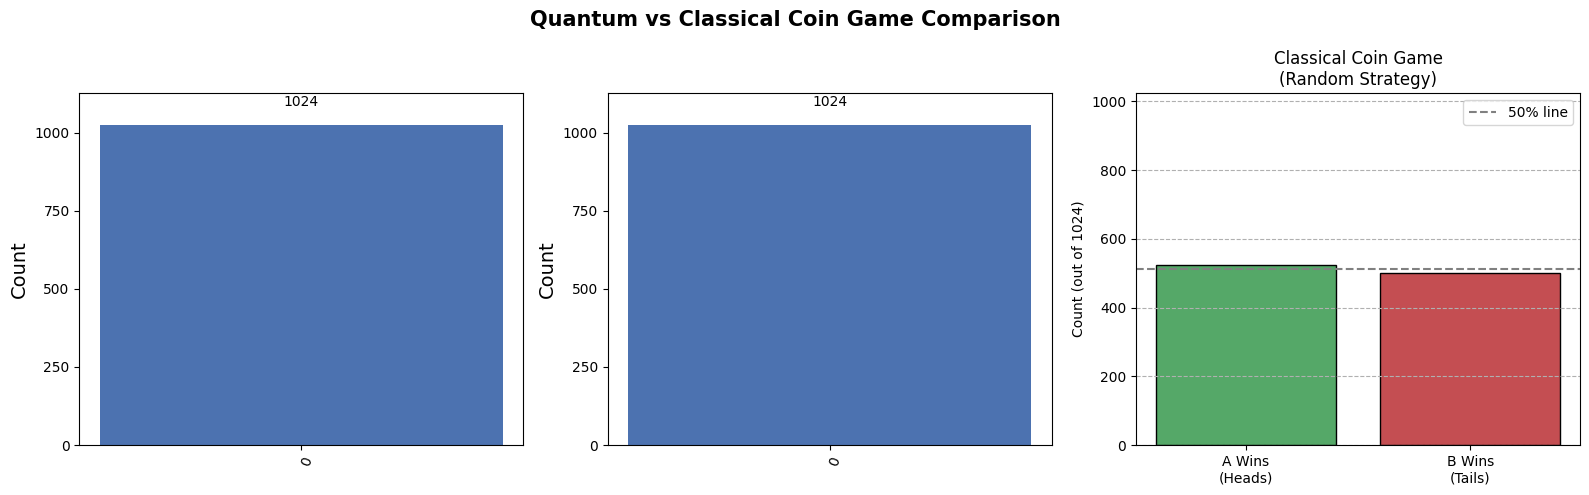


   EFFICIENCY COMPARISON SUMMARY
  Quantum Player Win Rate : 100.00%
  Classical Player Win Rate: ~50.00%
  Quantum Advantage       : ~50% improvement
  REASON: Q applies H twice — H·X·H = Z, H·I·H = I
  Both outcomes map |0⟩ → |0⟩ regardless of C's move!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_histogram(results_quantum['flip'],
               ax=axes[0],
               title="Quantum Game\n(C plays: Flip)\n0=Heads(Q wins), 1=Tails",
               color='#4C72B0')

plot_histogram(results_quantum['nothing'],
               ax=axes[1],
               title="Quantum Game\n(C plays: Nothing)\n0=Heads(Q wins), 1=Tails",
               color='#4C72B0')

axes[2].bar(['A Wins\n(Heads)', 'B Wins\n(Tails)'],
            [classical_w, classical_l],
            color=['#55a868', '#c44e52'],
            edgecolor='black')
axes[2].set_title("Classical Coin Game\n(Random Strategy)", fontsize=12)
axes[2].set_ylabel(f"Count (out of {num_games})")
axes[2].set_ylim(0, num_games)
axes[2].axhline(num_games/2, color='gray', linestyle='--', label='50% line')
axes[2].legend()

plt.suptitle("Quantum vs Classical Coin Game Comparison", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("=" * 55)
print("   EFFICIENCY COMPARISON SUMMARY")
print("=" * 55)
print(f"  Quantum Player Win Rate : 100.00%")
print(f"  Classical Player Win Rate: ~50.00%")
print(f"  Quantum Advantage       : ~50% improvement")
print("  REASON: Q applies H twice — H·X·H = Z, H·I·H = I")
print("  Both outcomes map |0⟩ → |0⟩ regardless of C's move!")

In [10]:
for move in ['flip', 'nothing']:
    qc_game = quantum_coin_game(classical_move=move)
    print(f"\nQuantum Coin Game Circuit – C plays '{move}':")
    print(qc_game.draw('text'))
    print()


Quantum Coin Game Circuit – C plays 'flip':
     ┌───┐ Q: H ┌───┐ C: X (Flip) ┌───┐ Q: H ┌─┐
  q: ┤ H ├──░───┤ X ├──────░──────┤ H ├──░───┤M├
     └───┘  ░   └───┘      ░      └───┘  ░   └╥┘
c: 1/═════════════════════════════════════════╩═
                                              0 


Quantum Coin Game Circuit – C plays 'nothing':
     ┌───┐ Q: H  C: I (Nothing) ┌───┐ Q: H ┌─┐
  q: ┤ H ├──░──────────░────────┤ H ├──░───┤M├
     └───┘  ░          ░        └───┘  ░   └╥┘
c: 1/═══════════════════════════════════════╩═
                                            0 

